# Динамика модели при изменении солнечной активности

Используем сценарий `:ramp`, при котором светимость сначала увеличивается,
а затем уменьшается. Строим графики численности маргариток, средней температуры
и светимости.

In [53]:
using DrWatson
using Agents
using CairoMakie
using DataFrames
using StatsBase
scatter(1:10)

include("/home/vvmalyuga/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab03/scripts/daisyworld-luminosity_lit.jl")

График динамики сохранён в /home/vvmalyuga/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab03/scripts/../plots/daisy_luminosity.png


## Агрегаторы

In [54]:
black(a) = a.breed == :black
white(a) = a.breed == :white
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (black, count)
 (white, count)

## Запуск модели со сценарием :ramp

In [55]:
model = daisyworld(solar_luminosity = 1.0, scenario = :ramp)

StandardABM with 360 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario

Функция для средней температуры

In [56]:
temperature(model) = StatsBase.mean(model.temperature)
mdata = [temperature, :solar_luminosity]

agent_df, model_df = run!(model, 1000; adata = adata, mdata = mdata)

(1001×3 DataFrame
  Row │ time   count_black  count_white 
      │ Int64  Int64        Int64       
──────┼─────────────────────────────────
    1 │     0          180          180
    2 │     1          394          165
    3 │     2          552          228
    4 │     3          588          287
    5 │     4          583          306
    6 │     5          578          318
    7 │     6          576          321
    8 │     7          576          319
    9 │     8          573          322
   10 │     9          565          328
   11 │    10          567          328
  ⋮   │   ⋮         ⋮            ⋮
  992 │   991            0          895
  993 │   992            0          900
  994 │   993            0          900
  995 │   994            0          900
  996 │   995            0          898
  997 │   996            0          896
  998 │   997            0          893
  999 │   998            0          896
 1000 │   999            0          895
 1001 │  1000           

## Построение комплексного графика

График численности, температуры и освещенности 

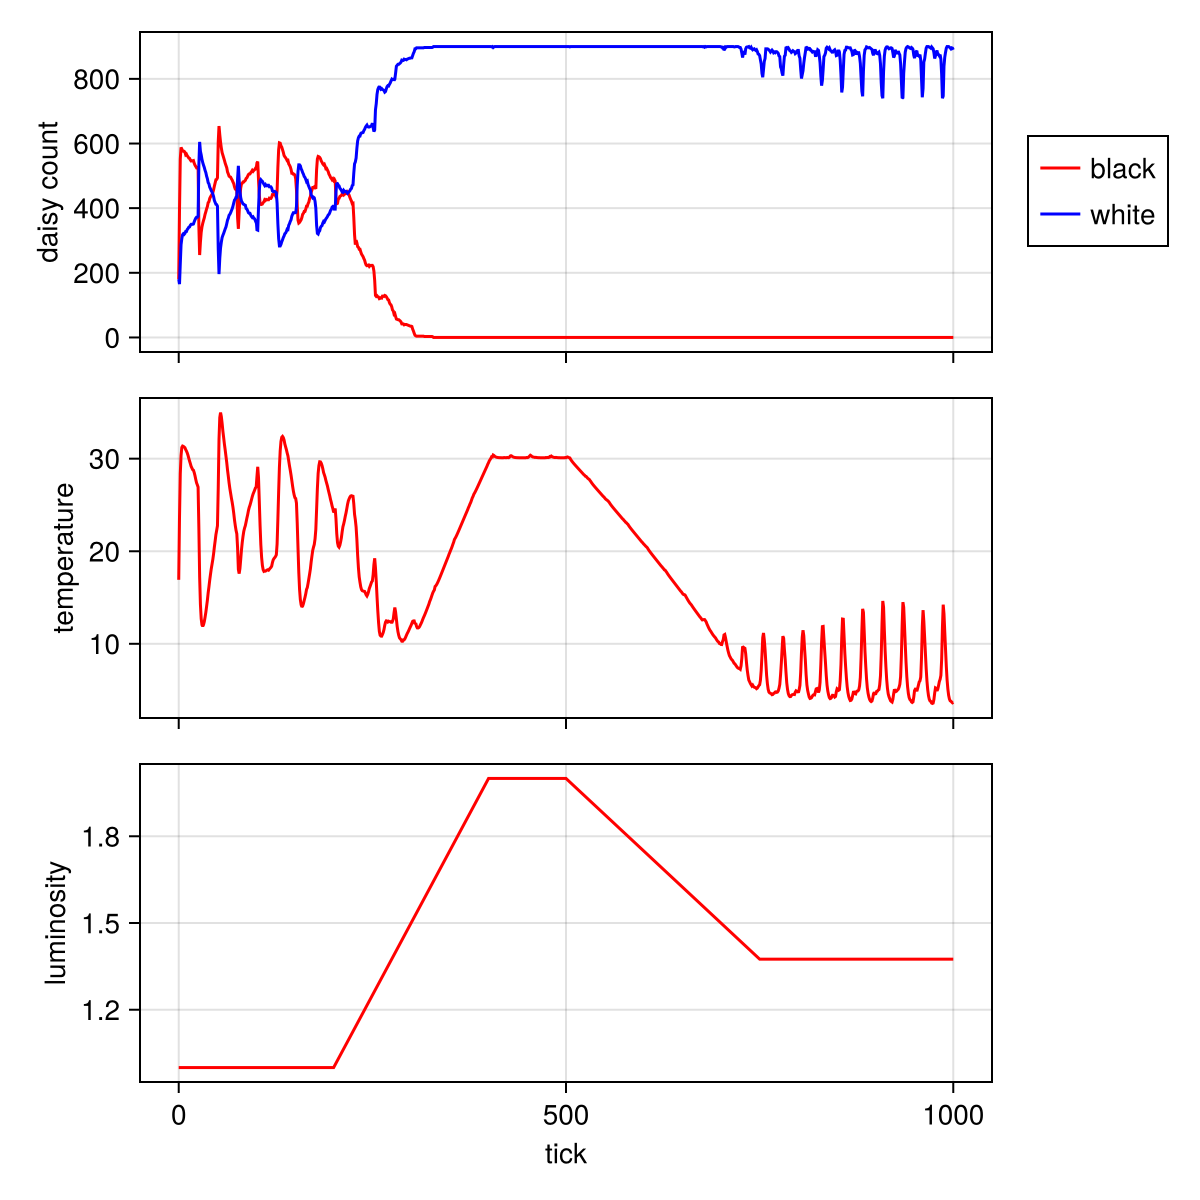

In [57]:
figure = CairoMakie.Figure(size = (600, 600))
ax1 = Axis(figure[1, 1], ylabel = "daisy count")
blackl = lines!(ax1, agent_df[!, :time], agent_df[!, :count_black], color = :red)
whitel = lines!(ax1, agent_df[!, :time], agent_df[!, :count_white], color = :blue)
figure[1, 2] = Legend(figure, [blackl, whitel], ["black", "white"])

ax2 = Axis(figure[2, 1], ylabel = "temperature")
lines!(ax2, model_df[!, :time], model_df[!, :temperature], color = :red)

ax3 = Axis(figure[3, 1], xlabel = "tick", ylabel = "luminosity")
lines!(ax3, model_df[!, :time], model_df[!, :solar_luminosity], color = :red)

for ax in (ax1, ax2)
    ax.xticklabelsvisible = false
end
figure

In [58]:
plots_dir = joinpath(@__DIR__, "..", "plots")
mkpath(plots_dir)
save(joinpath(plots_dir, "daisy_luminosity.png"), figure)

println("График динамики сохранён в $plots_dir/daisy_luminosity.png")

График динамики сохранён в /home/vvmalyuga/work/study/2026-1/2026-1--study--simulation-modeling/labs/project/notebooks/daisyworld-luminosity_lit/../plots/daisy_luminosity.png
